无监督学习  
我们只提供问题（特征数据），不提供答案（标签）。算法的任务是自行从数据中找出模式、结构或关系。

In [21]:
# 导入库
import os
# 在导入 numpy/scikit-learn 前限制 OpenMP 线程，规避 Windows + MKL 下 KMeans 的已知警告
os.environ['OMP_NUM_THREADS'] = '2'
os.environ['MKL_NUM_THREADS'] = '2'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.datasets import load_diabetes
from sklearn.model_selection import learning_curve
from sklearn.pipeline import make_pipeline
import warnings
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing 
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import mean_absolute_error
from sklearn import svm, datasets
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import TSNE



# 若运行时已加载线程库，兜底隐藏该已知 UserWarning，避免输出刷屏
warnings.filterwarnings(
    'ignore',
    message='KMeans is known to have a memory leak on Windows with MKL*',
    category=UserWarning
)

# 全局字体设置：自动选择系统中可用的中文字体，避免中文标题显示为方块
candidate_fonts = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Source Han Sans CN', 'Arial Unicode MS']
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
selected_font = next((f for f in candidate_fonts if f in available_fonts), None)
if selected_font:
    plt.rcParams['font.sans-serif'] = [selected_font]
plt.rcParams['axes.unicode_minus'] = False

经典聚类算法：K-Means  
K-Means 是最著名、最常用的聚类算法之一，其思想直观，实现相对简单。  
1. 算法原理与步骤  
我们可以把 K-Means 的过程想象成竞选代表并重新划区：  
1)确定簇的数量 K：首先，你需要决定想把数据分成几类。这个 K 值需要预先指定，这是 K-Means 的一个关键参数。  
2)初始化代表（质心）：随机在数据空间中选取 K 个点，作为每个簇的初始"中心点"，我们称之为质心。  
3)分配居民（样本）：计算数据集中每一个样本点到这 K 个质心的距离。遵循"近者归其类"的原则，将每个样本分配给距离它最近的那个质心所在的簇。这样，所有样本就被划分到了 K 个簇中。   
4)改选新代表更新质心）：现在，每个簇里都有了一批样本。重新计算每个簇的质心，新的质心就是该簇内所有样本点的平均值（均值点）。  
5)重复与收敛：重复步骤 3（分配）和步骤 4（更新），直到质心的位置不再发生显著变化（即算法收敛）。此时，每个样本的所属簇也不再变化。  

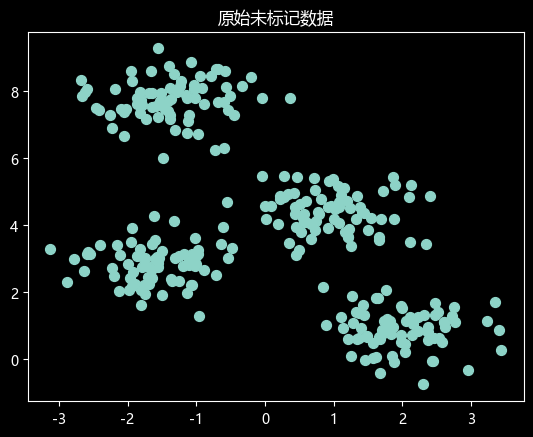

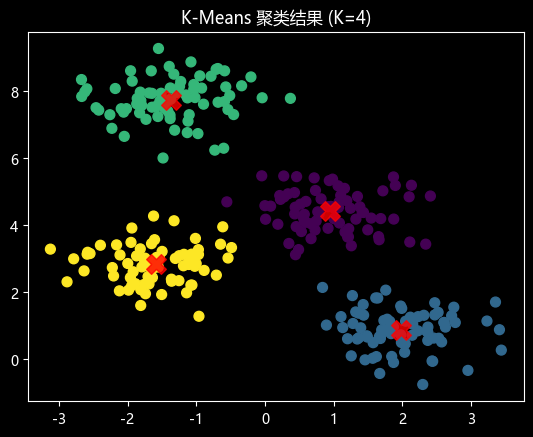

前10个样本的簇标签: [1 2 0 2 1 1 3 0 2 2]
四个簇的质心坐标:
 [[ 0.94973532  4.41906906]
 [ 1.98258281  0.86771314]
 [-1.37324398  7.75368871]
 [-1.58438467  2.83081263]]


In [16]:
# 1. 创建一个人工数据集
# 我们生成 300 个样本点，它们天然地围绕 4 个中心分布（方便我们观察）
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)
# X 是特征数据，y_true 是真实的类别标签（仅用于最后对比，聚类算法不会用到它）

# 2. 可视化原始数据
plt.scatter(X[:, 0], X[:, 1], s=50) # s 是点的大小
plt.title("原始未标记数据")
plt.show()

# 3. 应用 K-Means 聚类
# 指定要聚成 4 类
kmeans = KMeans(n_clusters=4, random_state=0, n_init='auto')
# 拟合模型并预测每个样本的簇标签
y_kmeans = kmeans.fit_predict(X)

# 4. 获取质心坐标
centroids = kmeans.cluster_centers_

# 5. 可视化聚类结果
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
# 用不同颜色标注不同簇的样本点

plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, alpha=0.8, marker='X')
# 用红色大叉标出质心位置，alpha 是透明度
plt.title("K-Means 聚类结果 (K=4)")
plt.show()

# 打印前10个样本的预测簇标签
print("前10个样本的簇标签:", y_kmeans[:10])
# 打印质心坐标
print("四个簇的质心坐标:\n", centroids)

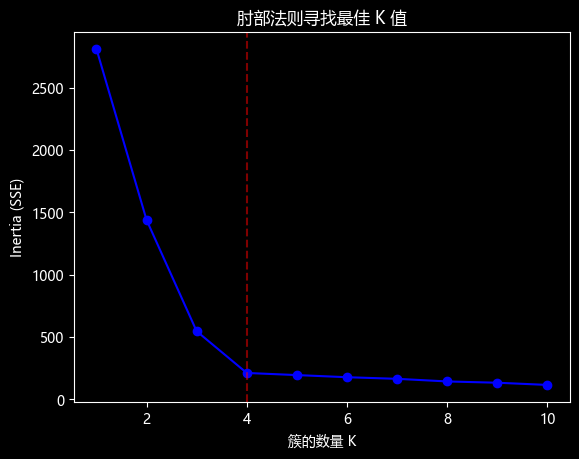

'观察生成的曲线，你会发现在 K=4 附近，曲线下降速度明显变缓，\n形成一个"肘部"，这提示我们 K=4 是一个合理的选择。\n'

In [17]:
"""
如何选择最佳的 K 值？
在上面的例子中，因为我们知道数据是围绕 4 个中心生成的，所以轻松地设置了 K=4。
但在现实世界中，我们往往不知道数据应该分成几类。如何选择 K 呢？
一个常用的方法是 "肘部法则"。其思想是：随着簇数量 K 的增加，
样本点到其所属簇质心的平均距离（称为畸变程度或 inertia）会下降。
当 K 小于真实簇数时，增加 K 会大幅降低这个距离；当 K 达到真实簇数后，再增加 K，
距离的下降幅度会骤减。这个拐点就像手肘的关节，对应的 K 值就是较好的选择。
"""


# 肘部法则示例：计算不同K值下的 inertia
inertias = []
K_range = range(1, 11) # 测试 K 从 1 到 10

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init='auto')
    kmeans.fit(X)
    inertias.append(kmeans.inertia_) # inertia_ 属性即 SSE

# 绘制肘部曲线
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('簇的数量 K')
plt.ylabel('Inertia (SSE)')
plt.title('肘部法则寻找最佳 K 值')
plt.axvline(x=4, color='r', linestyle='--', alpha=0.5) # 标记我们已知的 K=4
plt.show()

"""观察生成的曲线，你会发现在 K=4 附近，曲线下降速度明显变缓，
形成一个"肘部"，这提示我们 K=4 是一个合理的选择。
"""

降维  
1. 基本概念  
1)降维就是减少数据集特征数量的过程。它通过某种数学变换，将原始高维空间中的数据点，映射到一个新的、维度更低的空间中。
2. 核心价值
1)可视化：人类最多能直观理解三维空间。通过降维到 2D 或 3D，我们可以将高维数据画出来，直观地观察其结构、分组和异常点。  
2)提升效率：更少的数据维度意味着更小的存储空间、更快的训练速度和更低的计算成本。  
3)去除噪声与冗余：许多算法（尤其是距离计算类算法如KNN）在高维空间中会因不相关或重复的特征而性能下降。降维可以提炼出数据的精华。  
4)缓解维度灾难：在高维空间中，数据会变得极其稀疏，导致许多机器学习模型难以找到有效的模式。  
3. 核心思想：信息保留
降维的关键挑战是：如何在降低维度的同时，最大限度地保留原始数据中有价值的信息（如方差、数据结构）？ 不同的降维算法对此有不同的答案。
4. 主流降维算法
降维算法主要分为两大类：线性降维 和 非线性降维。   

线性降维：  
1)主成分分析  
主成分分析（PCA） 是最经典、最常用的线性降维方法。它的目标是为数据找到一组新的坐标轴（称为"主成分"），使得数据在这些新轴上的投影方差最大。  
2)PCA 的工作原理（四步走）：  
  a)中心化：将每个特征减去其平均值，使数据分布的中心移动到坐标原点。  
  b)计算协方差矩阵：这个矩阵描述了数据各个特征之间的相关性。  
  c)特征值分解：计算协方差矩阵的特征值和特征向量。特征向量 指明了新坐标轴（主成分）的方向，特征值 则代表了数据在该方向上的方差大小。特征值越大，该方向包含的信息越多。  
  d)选择主成分：将特征值从大到小排序，选择前 k 个最大的特征值对应的特征向量，构成一个投影矩阵。  
  e)数据转换：将原始数据乘以这个投影矩阵，就得到了降维到 k 维的新数据。   
3)PCA 的优缺点  
优点：计算高效，原理清晰，能有效去除线性相关性。  
缺点：它是一种线性方法，假设数据的主成分是线性的。对于像"瑞士卷"这样的非线性流形数据，PCA效果不佳。 

原始数据形状: (150, 4)
降维后数据形状: (150, 2)
各主成分解释的方差比例: [0.92461872 0.05306648]


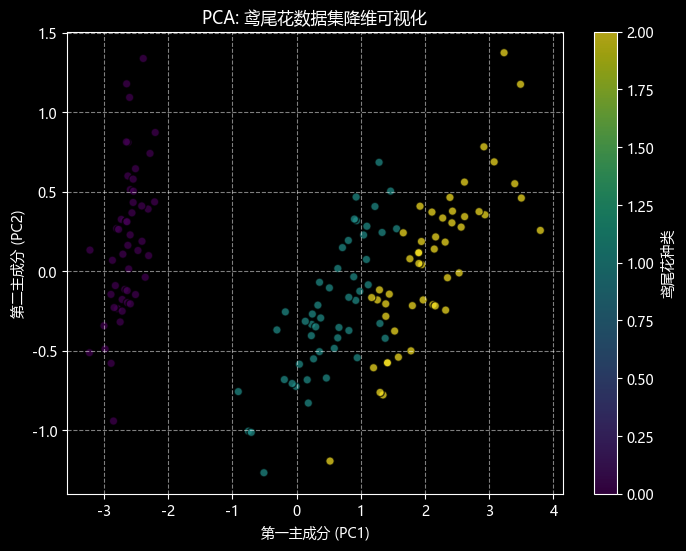

'\n代码解读：\nPCA(n_components=2)：初始化模型，n_components 参数指定要保留的主成分数量（即降维后的维度）。\nfit_transform(X)：这是一个组合方法，先计算数据的均值和主成分方向（fit），然后立即将数据转换到新空间（transform）。\nexplained_variance_ratio_：这是PCA一个非常重要的属性，\n它告诉我们每个新特征（主成分）保留了原始数据多少的方差（信息量）。这帮助我们决定选择多少个主成分是合适的。\n'

In [20]:
# 1. 加载经典的鸢尾花数据集（4个特征）
iris = load_iris()
X = iris.data  # 原始数据：150个样本，4个特征
y = iris.target # 标签，用于可视化着色

print(f"原始数据形状: {X.shape}")  # 输出: (150, 4)

# 2. 创建PCA模型，指定降维到2维
pca = PCA(n_components=2)

# 3. 拟合模型（计算主成分）并转换数据
X_pca = pca.fit_transform(X)

print(f"降维后数据形状: {X_pca.shape}") # 输出: (150, 2)
print(f"各主成分解释的方差比例: {pca.explained_variance_ratio_}")
# 输出可能类似: [0.9246, 0.0530] 表示第一主成分保留了92.5%的信息，第二主成分保留了5.3%

# 4. 可视化降维结果
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolor='k', alpha=0.7)
plt.xlabel('第一主成分 (PC1)')
plt.ylabel('第二主成分 (PC2)')
plt.title('PCA: 鸢尾花数据集降维可视化')
plt.colorbar(scatter, label='鸢尾花种类')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
"""
代码解读：
PCA(n_components=2)：初始化模型，n_components 参数指定要保留的主成分数量（即降维后的维度）。
fit_transform(X)：这是一个组合方法，先计算数据的均值和主成分方向（fit），然后立即将数据转换到新空间（transform）。
explained_variance_ratio_：这是PCA一个非常重要的属性，
它告诉我们每个新特征（主成分）保留了原始数据多少的方差（信息量）。这帮助我们决定选择多少个主成分是合适的。
"""

非线性降维：t-SNE  
当数据具有复杂的非线性结构时，我们需要非线性降维方法。t-分布随机邻域嵌入（t-SNE） 是当前最流行的可视化导向的非线性降维算法。

1. 核心思想
t-SNE 专注于保留数据的局部结构。它试图让在高维空间中"相似"（距离近）的点，在低维映射中也"相似"；而高维中"不相似"的点，在低维中则远离。  
2. t-SNE的优缺点  
优点：对复杂非线性数据的可视化效果极佳，能清晰展现聚类结构。  
缺点：  
1)计算速度慢，不适合大数据集。   
2)结果具有随机性，每次运行可能略有不同。  
3)超参数敏感，perplexity 需要调整。   
4)主要用于可视化（2D/3D），降维后的特征通常不用于后续的机器学习任务，因为其低维空间的距离意义发生了变化。  

瑞士卷数据形状: (1000, 3)


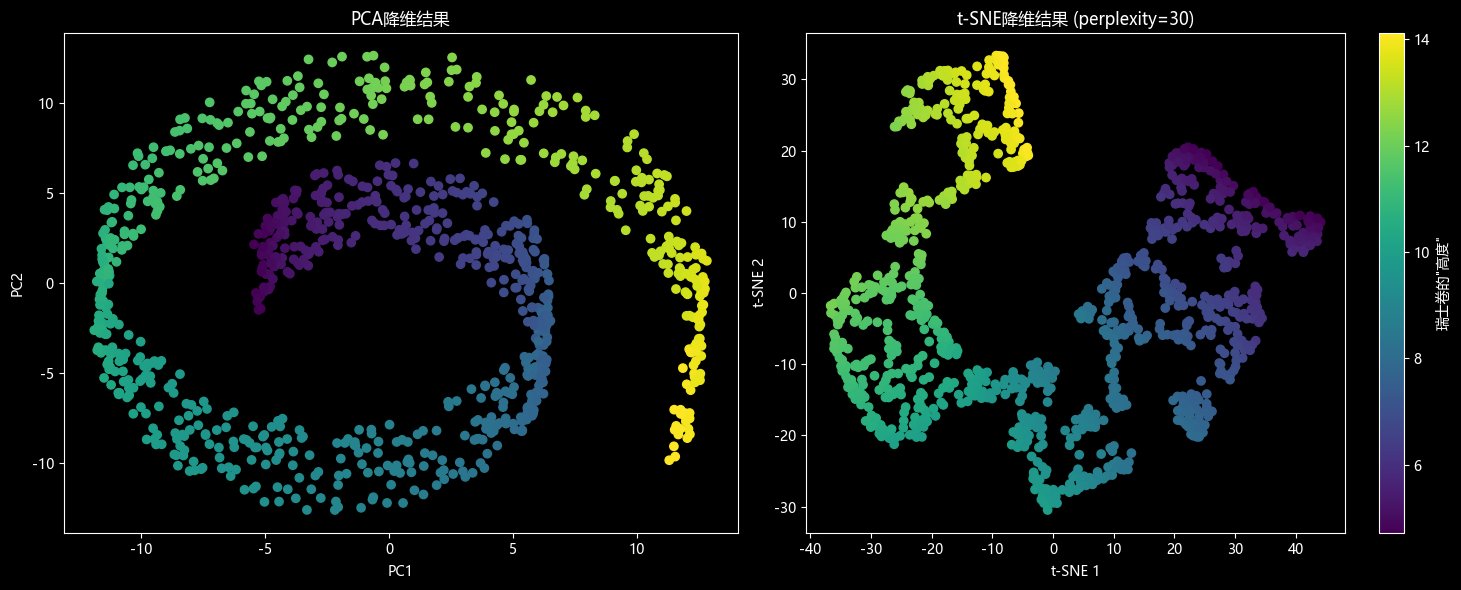

'\n代码解读：\nperplexity 参数：可以理解为对每个点考虑多少个近邻。值小则更关注局部结构，值大则更关注全局结构。\n它是t-SNE最重要的调参对象。\nrandom_state：确保结果可复现，因为t-SNE的优化过程是随机的。\n从可视化结果可以清晰看到，PCA将瑞士卷"压扁"了，丢失了其非线性卷曲结构；\n而t-SNE则更好地在二维平面上展开了这个卷，保留了数据的局部邻接关系。\n'

In [23]:
# 1. 生成一个非线性数据集：瑞士卷
X_swiss, color = make_swiss_roll(n_samples=1000, noise=0.1)
print(f"瑞士卷数据形状: {X_swiss.shape}") # (1000, 3)

# 2. 使用PCA（线性方法）尝试降维
pca = PCA(n_components=2)
X_swiss_pca = pca.fit_transform(X_swiss)

# 3. 使用t-SNE（非线性方法）降维
# perplexity（困惑度）是t-SNE的关键参数，通常介于5到50之间，表示对局部/全局结构的平衡关注
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_swiss_tsne = tsne.fit_transform(X_swiss)

# 4. 对比可视化
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# PCA结果
axes[0].scatter(X_swiss_pca[:, 0], X_swiss_pca[:, 1], c=color, cmap='viridis')
axes[0].set_title('PCA降维结果')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# t-SNE结果
sc = axes[1].scatter(X_swiss_tsne[:, 0], X_swiss_tsne[:, 1], c=color, cmap='viridis')
axes[1].set_title('t-SNE降维结果 (perplexity=30)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

plt.colorbar(sc, ax=axes[1], label='瑞士卷的"高度"')
plt.tight_layout()
plt.show()
"""
代码解读：
perplexity 参数：可以理解为对每个点考虑多少个近邻。值小则更关注局部结构，值大则更关注全局结构。
它是t-SNE最重要的调参对象。
random_state：确保结果可复现，因为t-SNE的优化过程是随机的。
从可视化结果可以清晰看到，PCA将瑞士卷"压扁"了，丢失了其非线性卷曲结构；
而t-SNE则更好地在二维平面上展开了这个卷，保留了数据的局部邻接关系。
"""